In [2]:
import pandas as pd

In [3]:
features_df=pd.read_csv("features.csv")
stores_df=pd.read_csv("stores.csv")
test_df=pd.read_csv("test.csv")
train_df=pd.read_csv("train.csv")

In [4]:
features_df.dtypes

Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

In [5]:
features_df["Date"] = pd.to_datetime(features_df["Date"])

In [6]:
features_df.dtypes

Store                    int64
Date            datetime64[us]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

In [7]:
stores_df.dtypes

Store    int64
Type       str
Size     int64
dtype: object

In [8]:
train_df.dtypes

Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object

In [9]:
train_df["Date"] = pd.to_datetime(train_df["Date"])
train_df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

In [10]:
test_df.dtypes

Store        int64
Dept         int64
Date           str
IsHoliday     bool
dtype: object

In [11]:
test_df["Date"] = pd.to_datetime(test_df["Date"])
test_df.dtypes

Store                 int64
Dept                  int64
Date         datetime64[us]
IsHoliday              bool
dtype: object

In [12]:
df = train_df.merge(features_df, how = "left")
df = df.merge(stores_df, how="left")
df = df.merge(test_df, how="left")

In [13]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [14]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [15]:
df2=df.drop(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], axis=1)

In [16]:
df2.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [17]:
df2 = df2[df2["Weekly_Sales"]>0]

In [18]:
df2.sort_values(by='Date')

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
140804,15,21,2010-02-05,3253.19,False,19.83,2.954,131.527903,8.350,B,123737
140661,15,20,2010-02-05,4606.90,False,19.83,2.954,131.527903,8.350,B,123737
140518,15,19,2010-02-05,1381.40,False,19.83,2.954,131.527903,8.350,B,123737
140408,15,18,2010-02-05,2239.25,False,19.83,2.954,131.527903,8.350,B,123737
...,...,...,...,...,...,...,...,...,...,...,...
173673,18,52,2012-10-26,2226.10,False,56.09,3.917,138.728161,8.243,B,120653
342211,36,16,2012-10-26,564.50,False,74.39,3.494,222.113657,6.228,A,39910
390158,41,92,2012-10-26,131128.24,False,41.80,3.686,199.219532,6.195,A,196321
175485,18,81,2012-10-26,14036.52,False,56.09,3.917,138.728161,8.243,B,120653


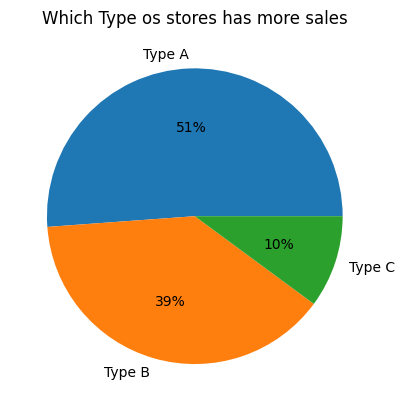

In [19]:
import matplotlib.pyplot as plt 
import numpy as np
stores=['Type A','Type B','Type C']
data=df2['Type'].value_counts()
fig, ax=plt.subplots()
plt.pie(data,labels=stores,autopct='%.0f%%')
ax.set_title('Which Type os stores has more sales')
plt.show()

Text(0.5, 1.0, 'Yearly Sales Trend from 2010-2012')

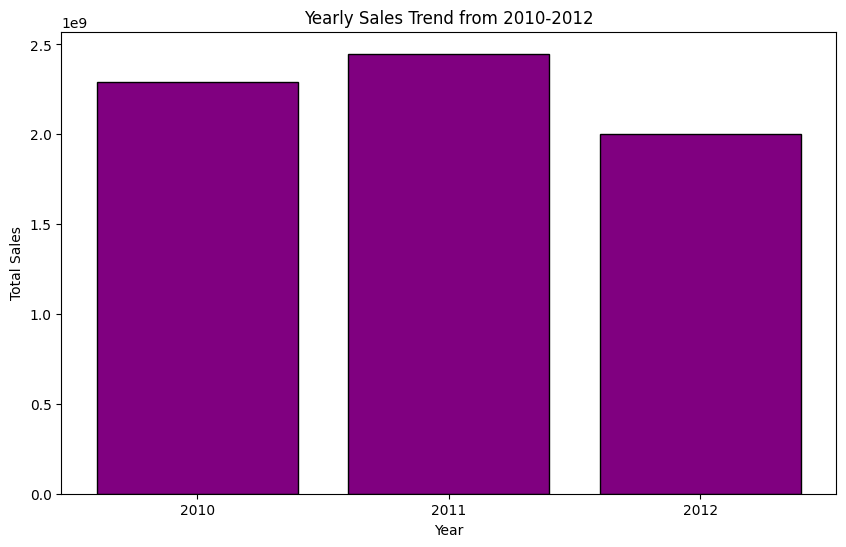

In [20]:
df2['Year']=df2['Date'].dt.year
Sales=df2.groupby(df2["Year"])["Weekly_Sales"].sum()
Yearly_Sales=Sales.head()
plt.figure(figsize=(10,6))
plt.bar(Yearly_Sales.index,Yearly_Sales.values,color='#800080',edgecolor='black')
plt.xticks(Yearly_Sales.index)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trend from 2010-2012")

Text(0, 0.5, 'Total Sales (M)')

<Figure size 1000x600 with 0 Axes>

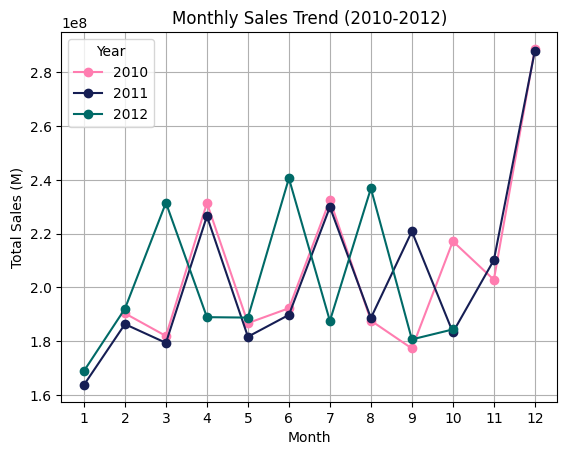

In [21]:
df2["Year"] = df2["Date"].dt.year
df2["Month"] = df2["Date"].dt.month
Monthly_sales = df2.groupby(['Year', 'Month'])['Weekly_Sales'].sum().unstack(level=0)

plt.figure(figsize=(10,6))
colors = "#FF7DB0", "#161E54", "#006A67"
Monthly_sales.plot(marker='o', color = colors)
plt.xticks(range(1,13))
plt.grid(True) 
plt.title("Monthly Sales Trend (2010-2012)")
plt.xlabel("Month")
plt.ylabel("Total Sales (M)")

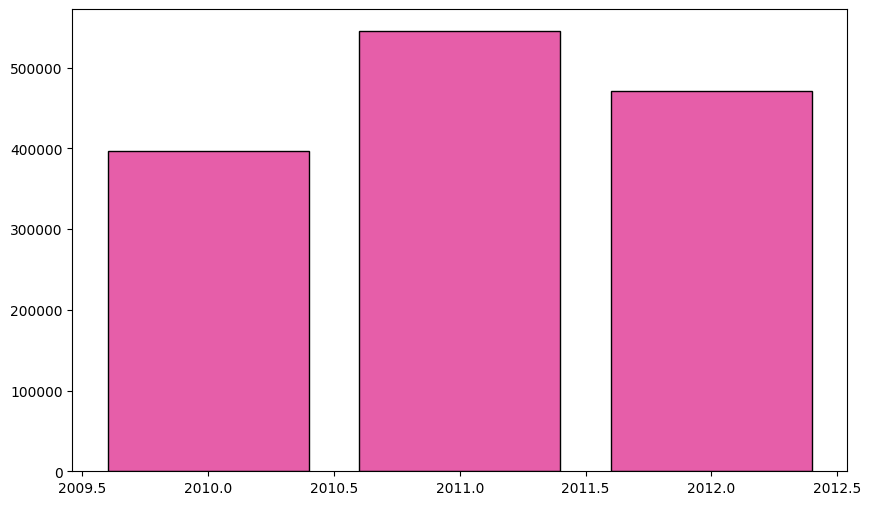

In [25]:
plt.figure(figsize=(10,6))
Fuel_effect = df2.groupby(['Year'])['Fuel_Price'].sum()
plt.bar(Fuel_effect.index, Fuel_effect.values, color = "#E65EA9", edgecolor='black')
plt.show()

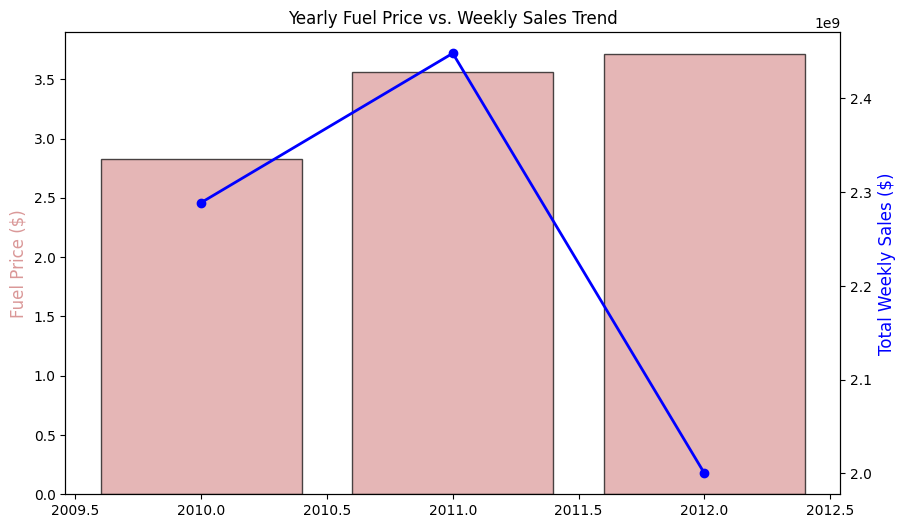

In [27]:
df2["Year"] = df2["Date"].dt.year
yearly_data = df2.groupby("Year").agg({"Fuel_Price": "mean", "Weekly_Sales": "sum"})
# yearly_data.head()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(yearly_data.index, yearly_data["Fuel_Price"], color="#DA9898", edgecolor='black', alpha=0.7, label="Avg Fuel Price")
ax1.set_ylabel("Fuel Price ($)", color="#DA9898", fontsize=12)


ax2 = ax1.twinx() 
ax2.plot(yearly_data.index, yearly_data["Weekly_Sales"], color="blue", marker='o', linewidth=2, label="Total Weekly Sales")
ax2.set_ylabel("Total Weekly Sales ($)", color="blue", fontsize=12)

plt.title("Yearly Fuel Price vs. Weekly Sales Trend")
plt.show()

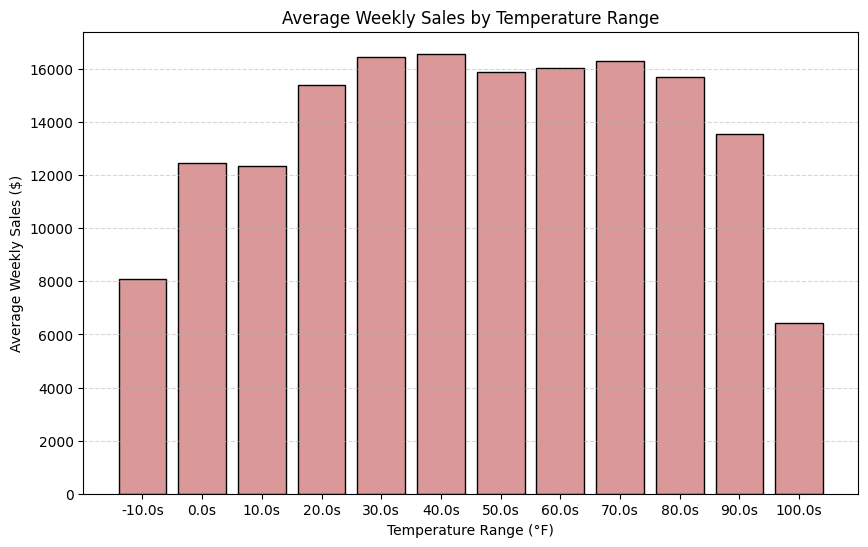

In [43]:
df['Temp_Bin'] = (df['Temperature'] // 10) * 10
temp_behavior = df.groupby('Temp_Bin')['Weekly_Sales'].mean()
plt.figure(figsize=(10, 6))
plt.bar(temp_behavior.index.astype(str) + "s", temp_behavior.values, color="#DA9898", edgecolor='black')
plt.title("Average Weekly Sales by Temperature Range")
plt.xlabel("Temperature Range (°F)")
plt.ylabel("Average Weekly Sales ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

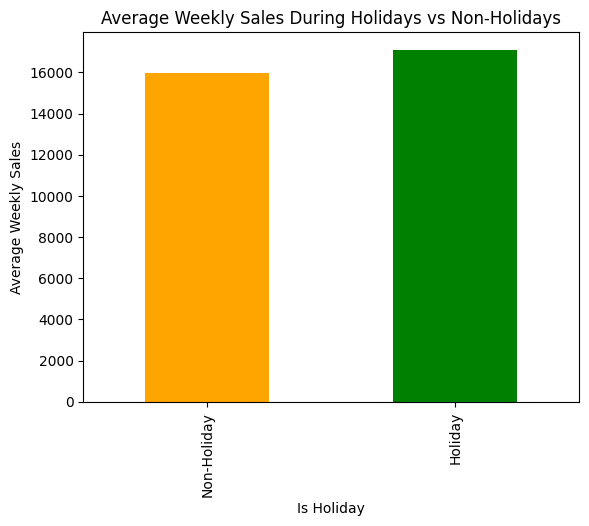

In [44]:

avg_sales = df2.groupby('IsHoliday')['Weekly_Sales'].mean()


avg_sales.plot(kind='bar', color=['orange', 'green'])
plt.title('Average Weekly Sales During Holidays vs Non-Holidays')
plt.xlabel('Is Holiday')
plt.ylabel('Average Weekly Sales')
plt.xticks(ticks=[0,1], labels=['Non-Holiday', 'Holiday'])
plt.show()